### Imports

In [163]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

### Reading the Image

In [164]:
img = cv.imread("output/lines_grid.png")
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

### Edge Detection using Canny

In [165]:
edges = cv.Canny(gray_img, 50, 250)

### Detecting Lines using Hough Transform

In [166]:
lines = cv.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=30,
    minLineLength=40,
    maxLineGap=10
)
hough_count = len(lines)


### Drawing Hough Lines

In [167]:
hough_img = np.full((600, 800, 3), 255, dtype=np.uint8)

for line in lines:
    x1, y1, x2, y2 = line
    cv.line(hough_img, (x1, y1), (x2, y2), (0,0,255), 2)

### Detecting Lines using LSD

In [ ]:
lsd = cv.createLineSegmentDetector()

detected = lsd.detect(gray_img)

### Drawing LSD Lines

In [169]:
lsd_img = np.full((600, 800, 3), 255, dtype=np.uint8)
lsd_count = 0

if detected[0] is not None:
    lsd_lines = detected[0]
    lsd_count = len(lsd_lines)

    lsd.drawSegments(lsd_img, lsd_lines)

### Display

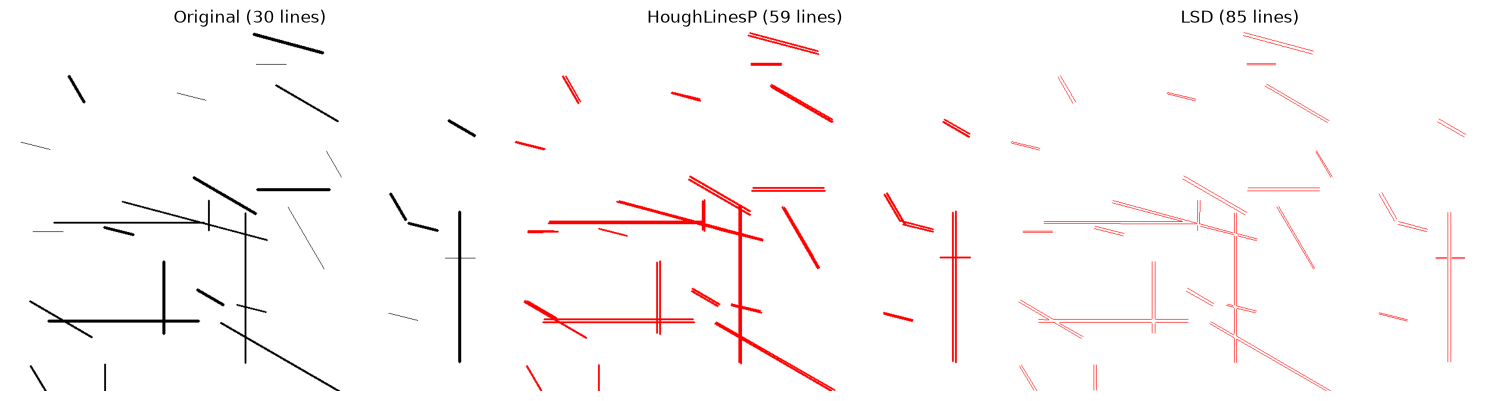

In [170]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original (30 lines)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(hough_img, cv.COLOR_BGR2RGB))
plt.title(f"HoughLinesP ({hough_count} lines)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(lsd_img, cv.COLOR_BGR2RGB))
plt.title(f"LSD ({lsd_count} lines)")
plt.axis("off")

plt.tight_layout()
plt.savefig("output/7_hough_lsd.png", dpi=300)
plt.show()

In [171]:
print("Ground Truth Lines :", 30)
print("HoughLinesP        :", hough_count)
print("LSD               :", lsd_count)

Ground Truth Lines : 30
HoughLinesP        : 59
LSD               : 85
